# OMR Benchmark Analyse – Notes2Tone
**Vergleich: OeMeR · HOMR · Audiveris · Audiveris-Scaled** | Datensatz: PRAIG/SMB

Metrik: **OMR-NED** (Normalized Edit Distance) – *niedriger = besser*

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = {
    'OeMeR':            '#E07B54',
    'HOMR':             '#5B8DB8',
    'Audiveris':        '#6BAD6B',
    'Audiveris-Scaled': '#9B72CF',
}
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
})

FIG_DIR = Path('figures/4_models')
FIG_DIR.mkdir(exist_ok=True)

## 1  Daten laden

In [48]:
RESULTS = Path('generated')

def load_csv(path: Path, model_name: str) -> pd.DataFrame:
    df = pd.read_csv(path, index_col=0, skipinitialspace=True)
    df.columns = df.columns.str.strip()
    df['model'] = model_name
    df['sample_id'] = df['gtpath'].str.extract(r'(sample_\d+)')
    df = df.dropna(subset=['sample_id']).copy()
    for col in df.columns:
        if col not in ('gtpath', 'predpath', 'model', 'sample_id'):
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

frames_raw = {
    'OeMeR':            load_csv(RESULTS / 'oemer_trimmed.csv',            'OeMeR'),
    'HOMR':             load_csv(RESULTS / 'homr_trimmed.csv',             'HOMR'),
    'Audiveris':        load_csv(RESULTS / 'audiveris_trimmed.csv',        'Audiveris'),
    'Audiveris-Scaled': load_csv(RESULTS / 'audiveris_scaled_trimmed.csv', 'Audiveris-Scaled'),
}

common_ids = set.intersection(*[set(df['sample_id']) for df in frames_raw.values()])
print(f'Samples pro Modell (vor Filter): { {k: len(v) for k, v in frames_raw.items()} }')
print(f'Gemeinsame Samples (Schnittmenge): {len(common_ids)}')

frames = {
    name: df[df['sample_id'].isin(common_ids)].copy().reset_index(drop=True)
    for name, df in frames_raw.items()
}

all_df = pd.concat(frames.values(), ignore_index=True)

NED_COL   = 'OMR-NED (OMR-ED / total numsyms)'
ED_COL    = 'OMR-ED (OMR Edit Distance)'
GT_COL    = 'gt numsyms'
PRED_COL  = 'pred numsyms'
TOTAL_COL = 'total numsyms (in both scores)'

PCT_COLS = [c for c in all_df.columns if '% contribution to OMR-NED' in c]

print()
for name, df in frames.items():
    print(f'{name:20s}  {len(df):>4d} Samples  |  NED Ø={df[NED_COL].mean():.3f}  Median={df[NED_COL].median():.3f}')


Samples pro Modell (vor Filter): {'OeMeR': 581, 'HOMR': 680, 'Audiveris': 201, 'Audiveris-Scaled': 538}
Gemeinsame Samples (Schnittmenge): 104

OeMeR                  104 Samples  |  NED Ø=0.693  Median=0.715
HOMR                   104 Samples  |  NED Ø=0.339  Median=0.243
Audiveris              104 Samples  |  NED Ø=0.368  Median=0.321
Audiveris-Scaled       104 Samples  |  NED Ø=0.326  Median=0.250


## 2  Deskriptive Statistik – OMR-NED

In [49]:
stats_rows = []
for name, df in frames.items():
    ned = df[NED_COL]
    stats_rows.append({
        'Modell':       name,
        'n':            len(df),
        'Mittelwert':   ned.mean(),
        'Median':       ned.median(),
        'Std':          ned.std(),
        'Min':          ned.min(),
        'Max':          ned.max(),
        'Q25':          ned.quantile(0.25),
        'Q75':          ned.quantile(0.75),
    })

stats_df = pd.DataFrame(stats_rows).set_index('Modell')
display(stats_df.style
    .format({
        'n': '{:.0f}',
        'Mittelwert': '{:.4f}', 'Median': '{:.4f}', 'Std': '{:.4f}',
        'Min': '{:.4f}', 'Max': '{:.4f}', 'Q25': '{:.4f}', 'Q75': '{:.4f}',
    })
    .background_gradient(cmap='RdYlGn_r', subset=['Mittelwert', 'Median'])
    .set_caption('OMR-NED Statistik – niedrigere Werte = bessere Performance')
)

,n,Mittelwert,Median,Std,Min,Max,Q25,Q75
Modell,,,,,,,,
OeMeR,104,0.6933,0.7148,0.1887,0.2457,0.9807,0.5706,0.8443
HOMR,104,0.3392,0.2430,0.2446,0.0192,0.9526,0.1437,0.5694
Audiveris,104,0.3678,0.3207,0.2575,0.0093,0.9733,0.1701,0.5863
Audiveris-Scaled,104,0.3262,0.2496,0.2597,0.0169,0.9625,0.1088,0.5062


## 3  Mittelwert & Median – Balkendiagramm

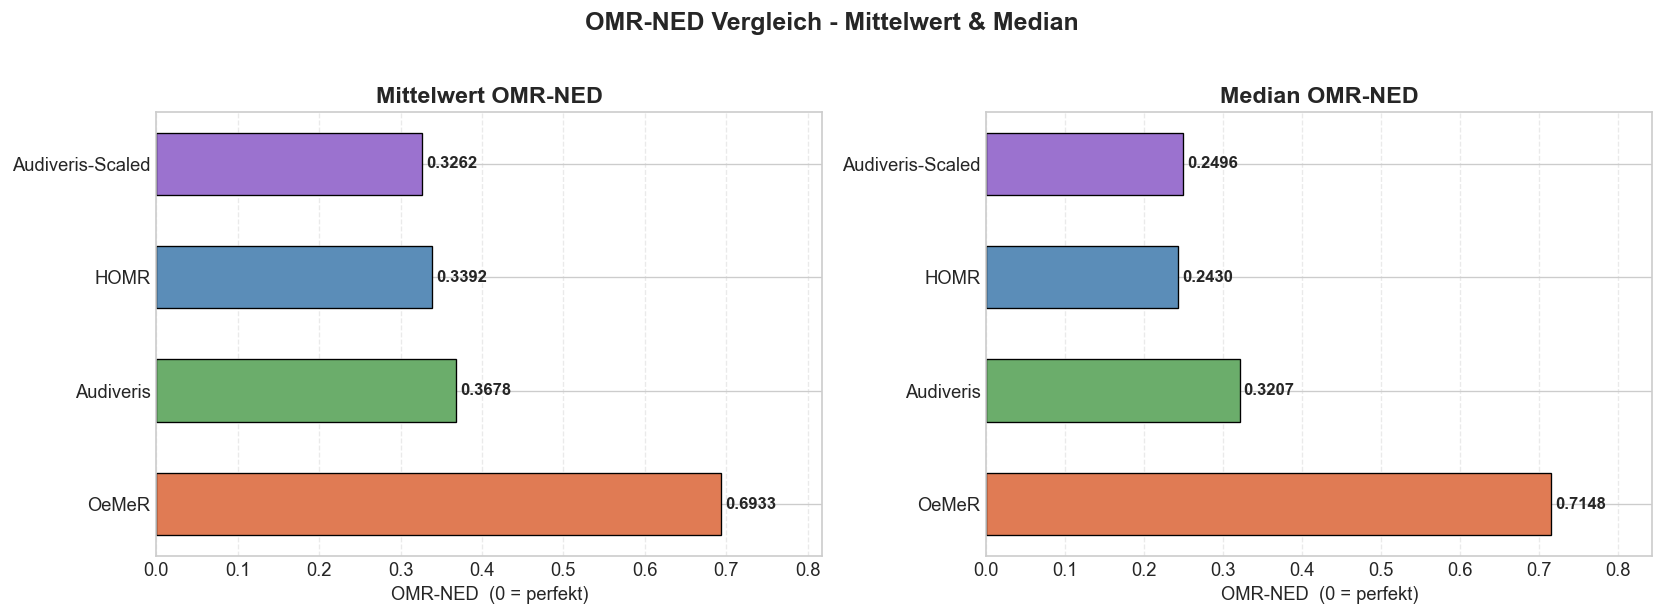

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
model_order = sorted(frames.keys(), key=lambda m: frames[m][NED_COL].mean())
colors = [PALETTE[m] for m in model_order]

for ax, stat, title in zip(
    axes,
    ['mean', 'median'],
    ['Mittelwert OMR-NED', 'Median OMR-NED'],
):
    vals = [getattr(frames[m][NED_COL], stat)() for m in model_order]
    bars = ax.barh(model_order, vals, color=colors, edgecolor='black', linewidth=0.8, height=0.55)
    for bar, v in zip(bars, vals):
        ax.text(v + 0.005, bar.get_y() + bar.get_height() / 2,
                f'{v:.4f}', va='center', ha='left', fontsize=10, fontweight='bold')
    ax.set_xlim(0, max(vals) * 1.18)
    ax.set_title(title)
    ax.set_xlabel('OMR-NED  (0 = perfekt)')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.4, linestyle='--')

fig.suptitle('OMR-NED Vergleich - Mittelwert & Median', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'ned_mean_median_bar.png', dpi=200, bbox_inches='tight')
plt.show()

## 4  Verteilungsdiagramm (KDE)

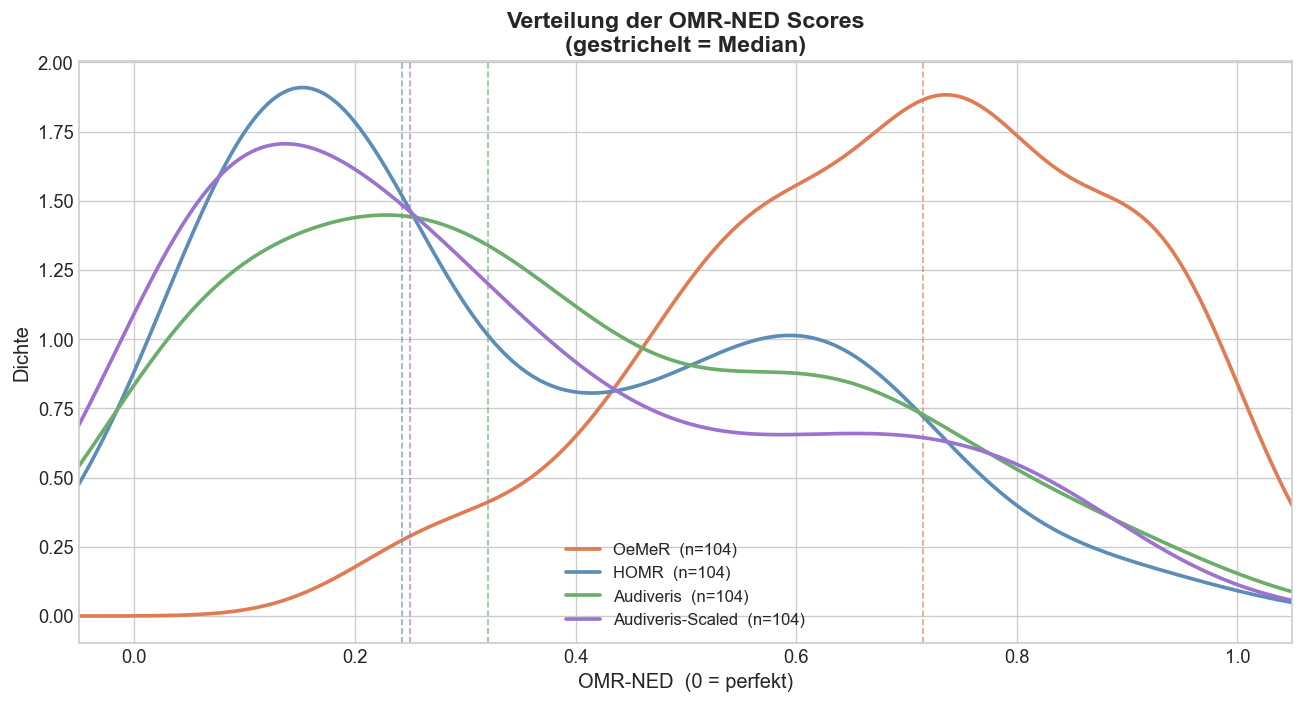

In [51]:
fig, ax = plt.subplots(figsize=(11, 6))

for name, df in frames.items():
    ned = df[NED_COL].dropna()
    ned.plot.kde(ax=ax, label=f'{name}  (n={len(df)})', color=PALETTE[name], linewidth=2.2)
    ax.axvline(ned.median(), color=PALETTE[name], linestyle='--', linewidth=1.0, alpha=0.7)

ax.set_xlabel('OMR-NED  (0 = perfekt)', fontsize=12)
ax.set_ylabel('Dichte', fontsize=12)
ax.set_title('Verteilung der OMR-NED Scores\n(gestrichelt = Median)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim(-0.05, 1.05)
plt.tight_layout()
plt.savefig(FIG_DIR / 'ned_distribution_kde.png', dpi=200, bbox_inches='tight')
plt.show()

## 5  Histogramme (pro Modell)

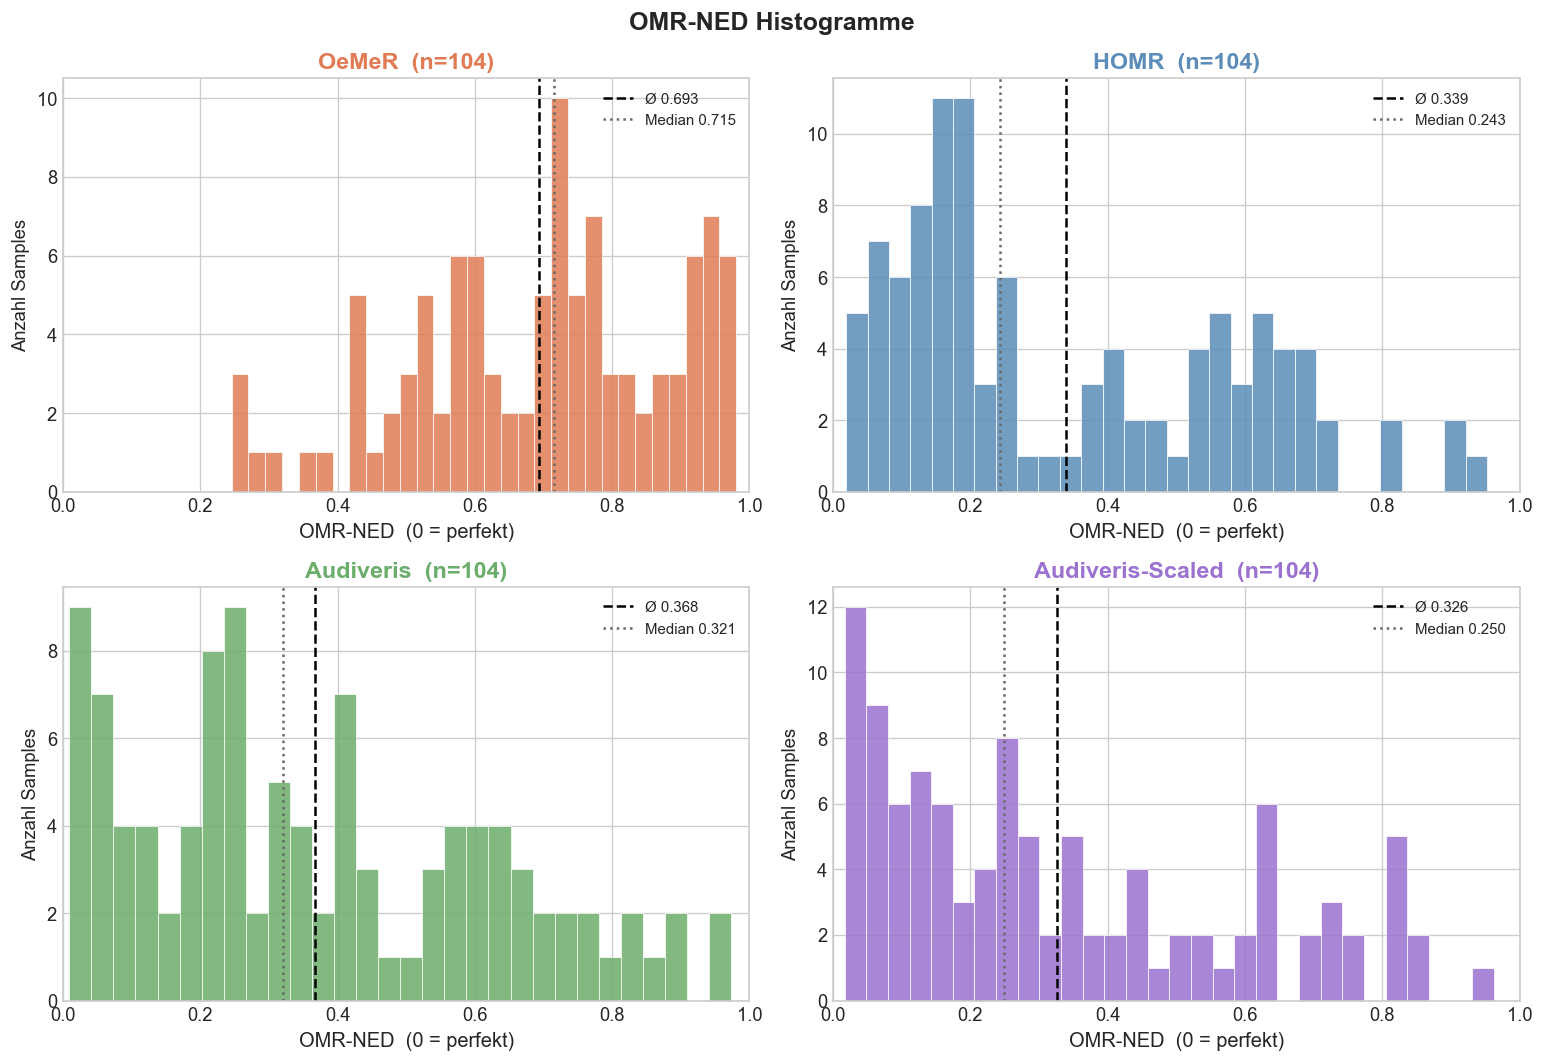

In [52]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharey=False)
axes = axes.flatten()

for ax, (name, df) in zip(axes, frames.items()):
    ned = df[NED_COL].dropna()
    ax.hist(ned, bins=30, color=PALETTE[name], edgecolor='white', linewidth=0.5, alpha=0.85)
    ax.axvline(ned.mean(),   color='black',  linestyle='--', linewidth=1.5, label=f'Ø {ned.mean():.3f}')
    ax.axvline(ned.median(), color='dimgray', linestyle=':',  linewidth=1.5, label=f'Median {ned.median():.3f}')
    ax.set_title(f'{name}  (n={len(df)})', color=PALETTE[name], fontweight='bold')
    ax.set_xlabel('OMR-NED  (0 = perfekt)', fontsize=12)
    ax.set_ylabel('Anzahl Samples')
    ax.legend(fontsize=9)
    ax.set_xlim(0, 1)

fig.suptitle('OMR-NED Histogramme', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'ned_histograms.png', dpi=200, bbox_inches='tight')
plt.show()

## 6  Boxplot

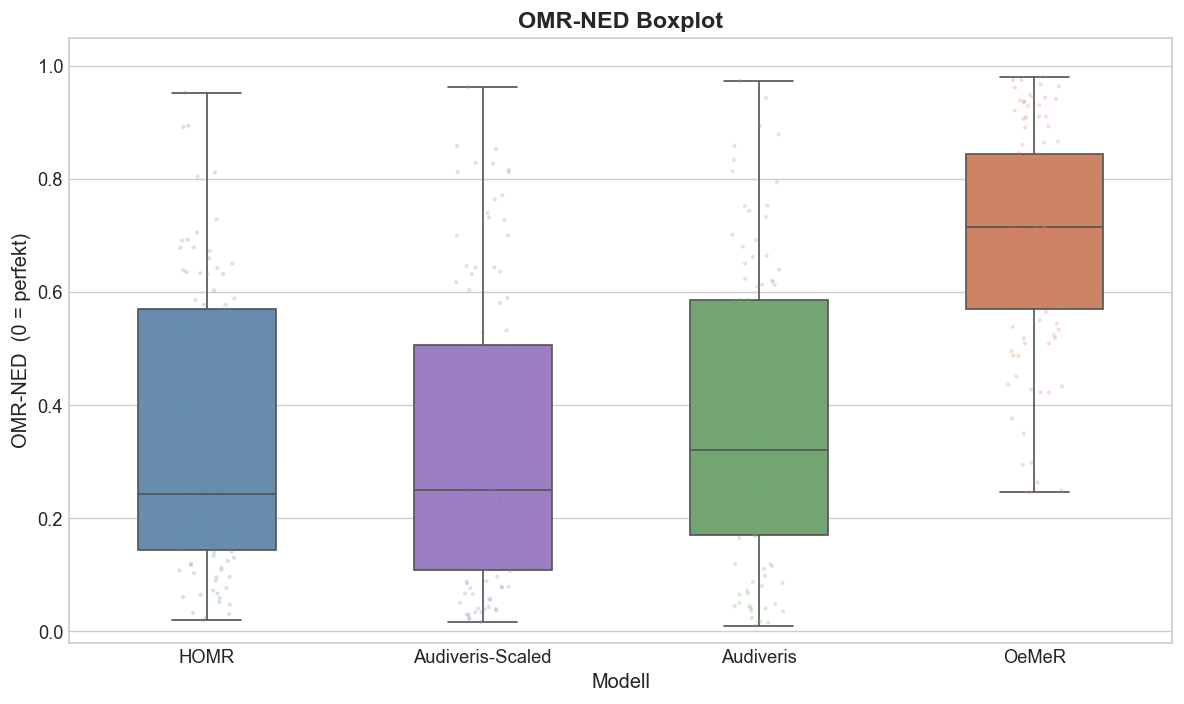

In [53]:
fig, ax = plt.subplots(figsize=(10, 6))

order = sorted(frames.keys(), key=lambda m: frames[m][NED_COL].median())
plot_df = all_df[all_df['model'].isin(order)].copy()

sns.boxplot(
    data=plot_df,
    x='model', y=NED_COL, hue='model',
    order=order,
    palette=PALETTE,
    width=0.5, legend=False,
    flierprops=dict(marker='o', markersize=3, alpha=0.4),
    ax=ax,
)
sns.stripplot(
    data=plot_df,
    x='model', y=NED_COL, hue='model',
    order=order,
    palette=PALETTE,
    size=2.5, alpha=0.25, jitter=True, legend=False, ax=ax,
)

ax.set_xlabel('Modell', fontsize=12)
ax.set_ylabel('OMR-NED  (0 = perfekt)', fontsize=12)
ax.set_title('OMR-NED Boxplot', fontsize=14, fontweight='bold')
ax.set_ylim(-0.02, 1.05)
plt.tight_layout()
plt.savefig(FIG_DIR / 'ned_boxplot.png', dpi=200, bbox_inches='tight')
plt.show()

## 7  Ground Truth vs. Erkannte Symbole

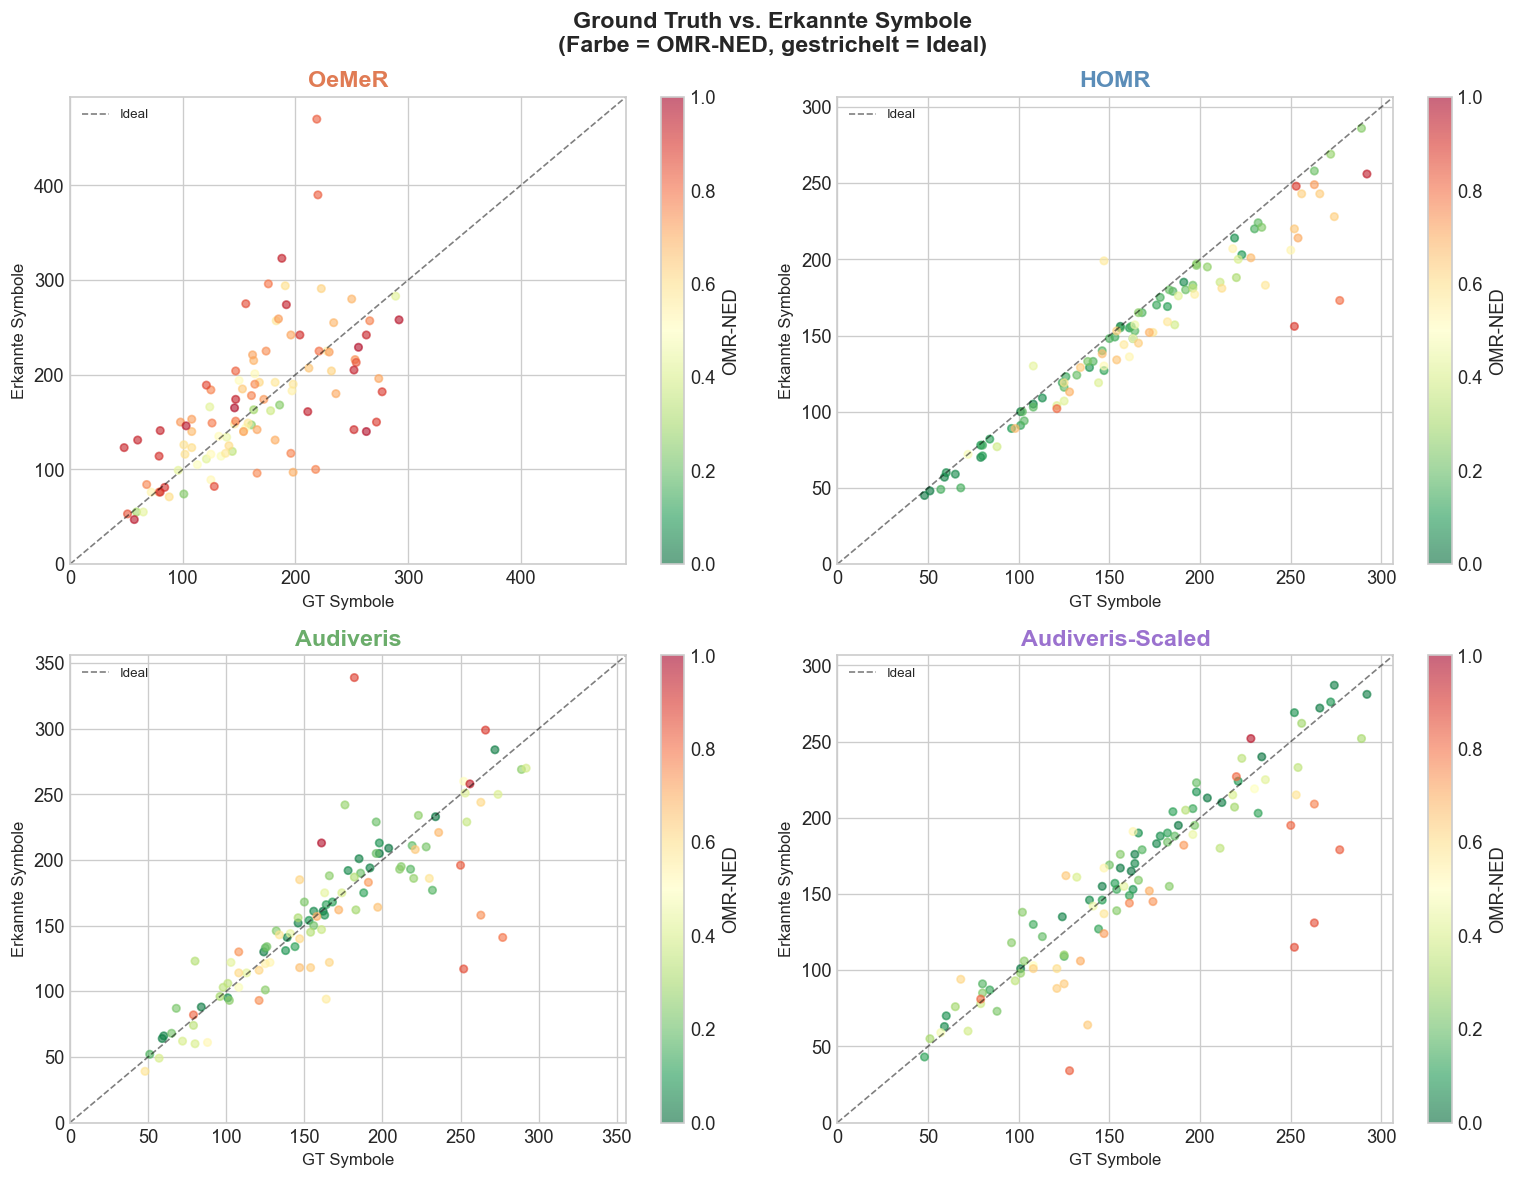

In [54]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for ax, (name, df) in zip(axes, frames.items()):
    sub = df[[GT_COL, PRED_COL, NED_COL]].dropna()
    gt   = sub[GT_COL].values
    pred = sub[PRED_COL].values
    ned  = sub[NED_COL].values

    sc = ax.scatter(gt, pred, c=ned,
                    cmap='RdYlGn_r', alpha=0.6, s=20, vmin=0, vmax=1)
    lim = max(gt.max(), pred.max()) * 1.05
    ax.plot([0, lim], [0, lim], 'k--', linewidth=1, alpha=0.5, label='Ideal')
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel('GT Symbole', fontsize=10)
    ax.set_ylabel('Erkannte Symbole', fontsize=10)
    ax.set_title(name, color=PALETTE[name], fontweight='bold')
    ax.legend(fontsize=8)
    plt.colorbar(sc, ax=ax, label='OMR-NED')

fig.suptitle('Ground Truth vs. Erkannte Symbole\n(Farbe = OMR-NED, gestrichelt = Ideal)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'symbols_scatter.png', dpi=200, bbox_inches='tight')
plt.show()

### 7b  Symbolanzahl-Boxplot (GT vs. Predicted)

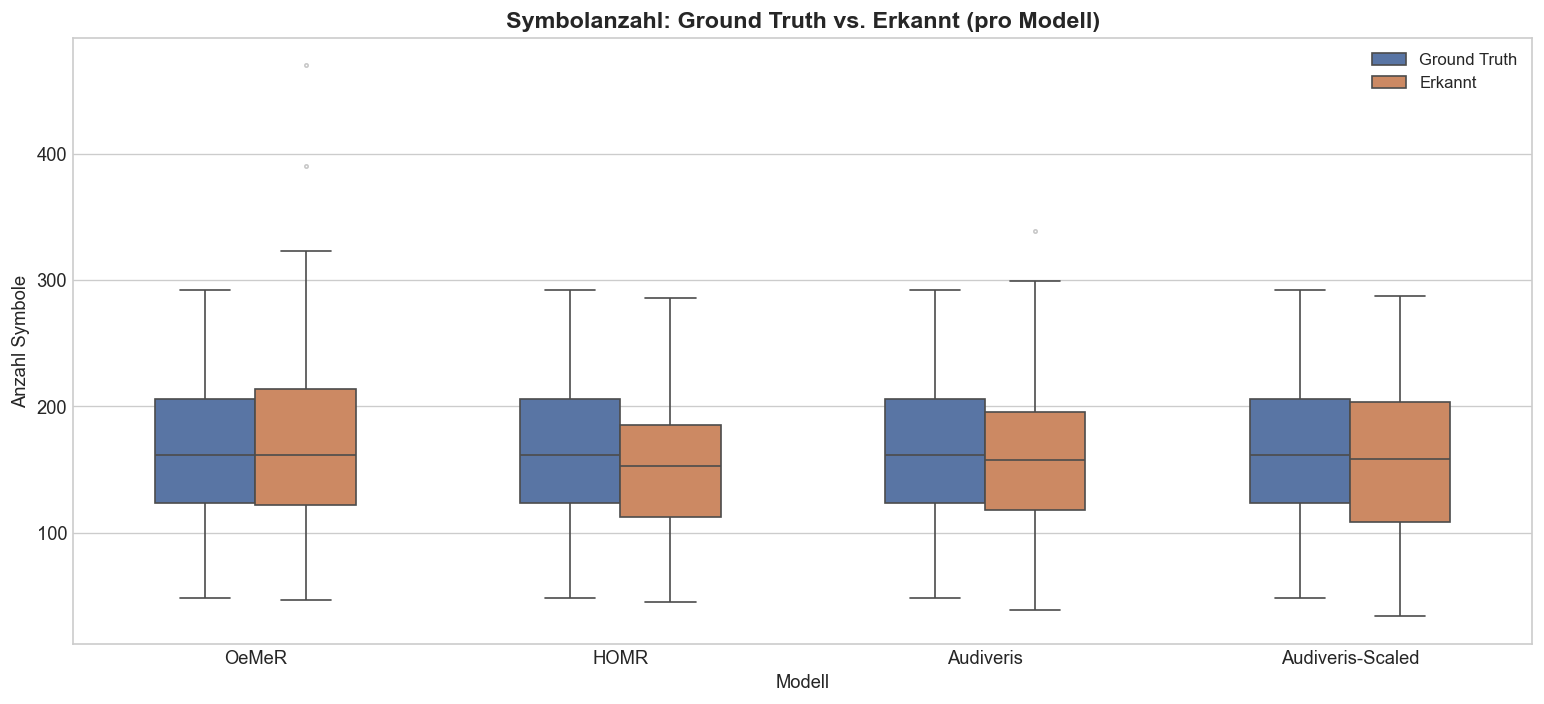

In [55]:
sym_rows = []
for name, df in frames.items():
    for _, row in df[[GT_COL, PRED_COL]].dropna().iterrows():
        sym_rows.append({'Modell': name, 'Typ': 'Ground Truth', 'Symbole': row[GT_COL]})
        sym_rows.append({'Modell': name, 'Typ': 'Erkannt',      'Symbole': row[PRED_COL]})
sym_df = pd.DataFrame(sym_rows)

fig, ax = plt.subplots(figsize=(13, 6))
sns.boxplot(
    data=sym_df,
    x='Modell', y='Symbole', hue='Typ',
    palette={'Ground Truth': '#4C72B0', 'Erkannt': '#DD8452'},
    width=0.55,
    flierprops=dict(marker='o', markersize=2, alpha=0.3),
    ax=ax,
)
ax.set_title('Symbolanzahl: Ground Truth vs. Erkannt (pro Modell)', fontsize=14, fontweight='bold')
ax.set_ylabel('Anzahl Symbole')
ax.legend(title='', fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / 'symbols_boxplot_gt_pred.png', dpi=200, bbox_inches='tight')
plt.show()

## 8  Fehlertypen-Analyse
Welche Symbol-Kategorien sind am schwierigsten? (**%-Beitrag zum OMR-NED**)

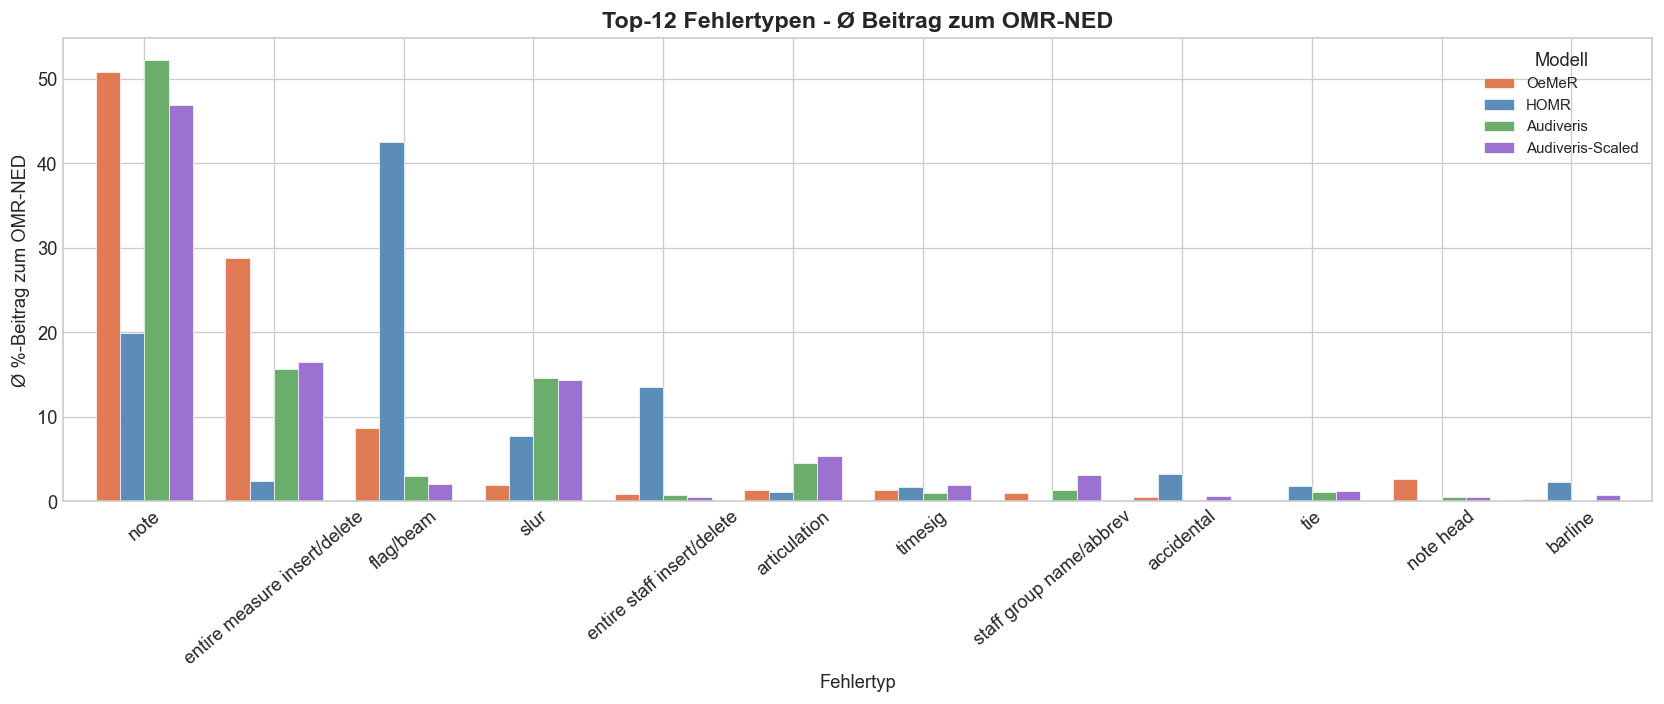

In [56]:
def clean_err_name(col: str) -> str:
    return col.replace('% contribution to OMR-NED', '').replace('wrong ', '').strip()

err_data = {}
for name, df in frames.items():
    means = df[PCT_COLS].mean()
    means.index = [clean_err_name(c) for c in means.index]
    err_data[name] = means

err_df = pd.DataFrame(err_data).T

top_errors = err_df.mean().nlargest(12).index.tolist()
err_top = err_df[top_errors]

fig, ax = plt.subplots(figsize=(14, 6))
err_top.T.plot(kind='bar', ax=ax,
               color=[PALETTE[m] for m in err_top.index],
               width=0.75, edgecolor='white', linewidth=0.4)
ax.set_xlabel('Fehlertyp', fontsize=11)
ax.set_ylabel('Ø %-Beitrag zum OMR-NED', fontsize=11)
ax.set_title('Top-12 Fehlertypen - Ø Beitrag zum OMR-NED', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=40)
ax.legend(title='Modell', fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / 'error_types_bar.png', dpi=200, bbox_inches='tight')
plt.show()

### 8b  Fehlertypen Heatmap

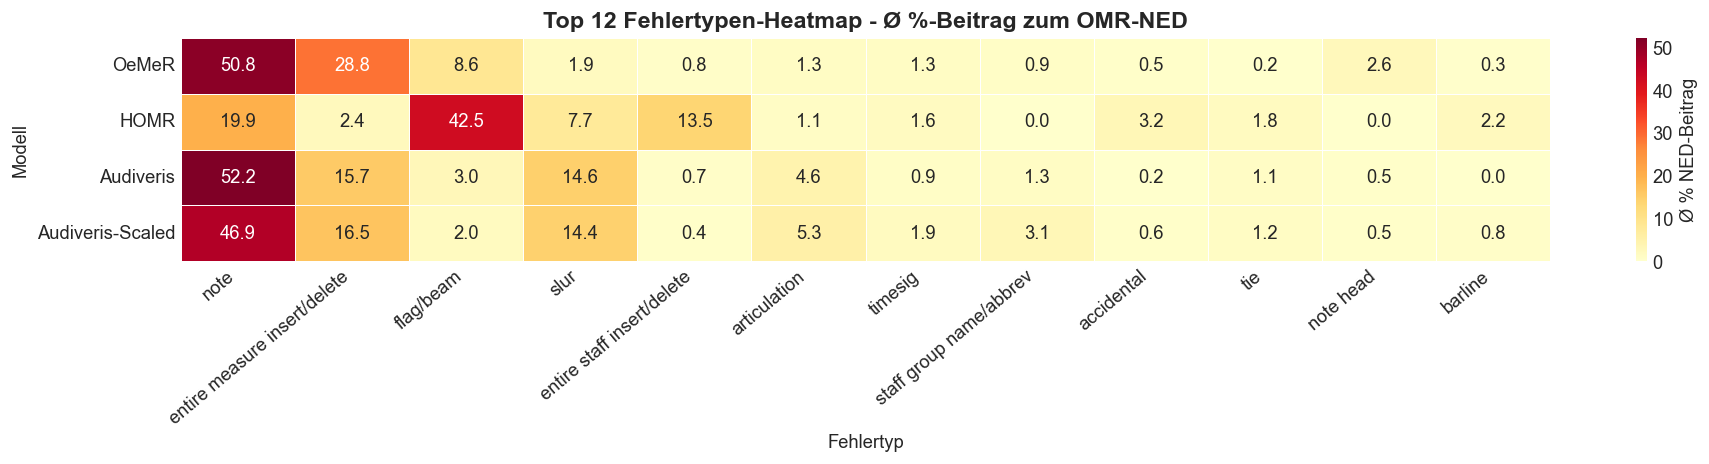

In [57]:
fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(
    err_top,
    annot=True, fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Ø % NED-Beitrag'},
    ax=ax,
)
ax.set_title('Top 12 Fehlertypen-Heatmap - Ø %-Beitrag zum OMR-NED', fontsize=14, fontweight='bold')
ax.set_xlabel('Fehlertyp')
ax.set_ylabel('Modell')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.savefig(FIG_DIR / 'error_types_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()

## 9  Positive & Negative Beispiele
Beste (niedrigster NED) und schlechteste (höchster NED) Samples pro Modell.

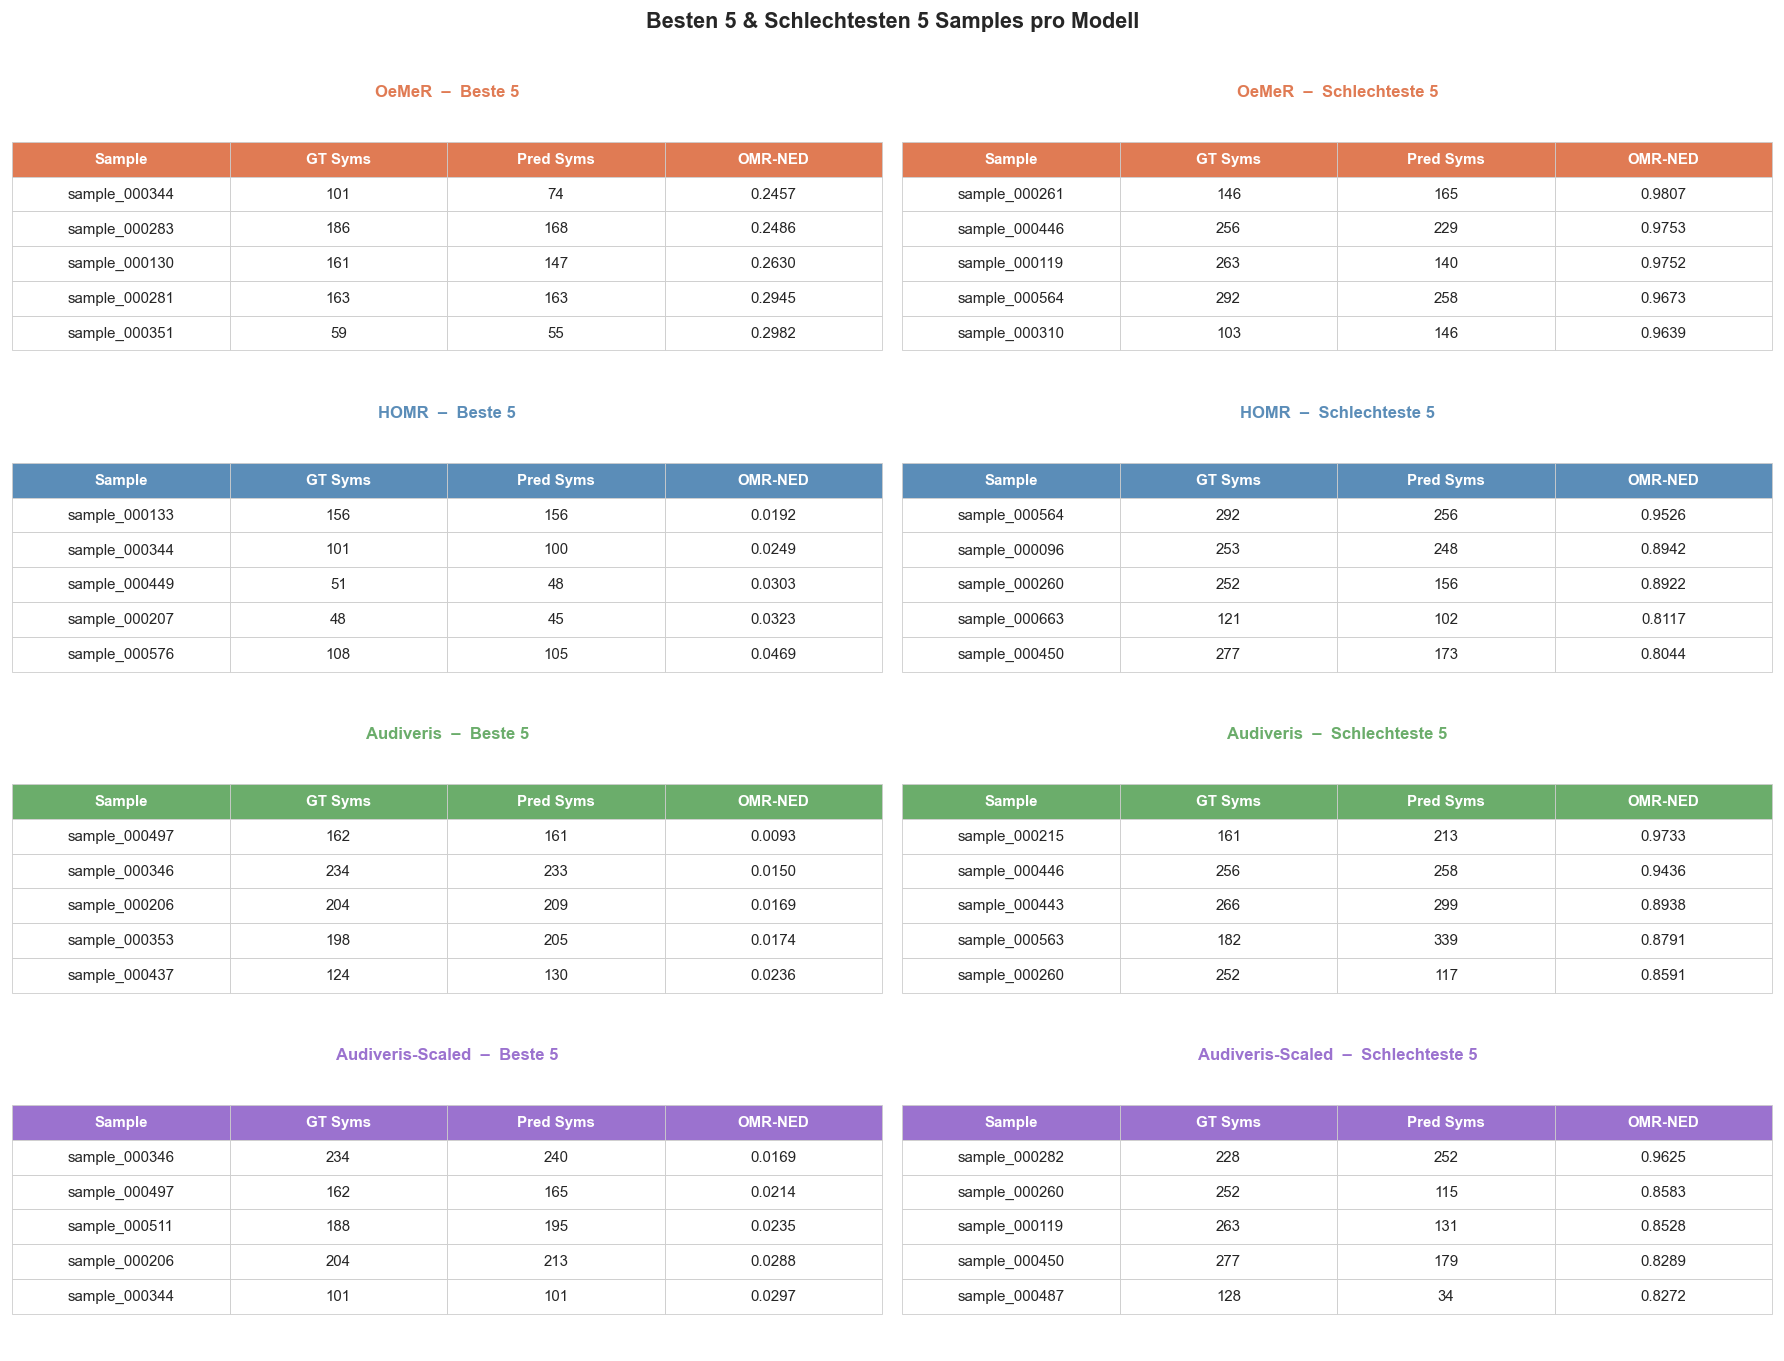

In [58]:
DISPLAY_COLS = ['sample_id', GT_COL, PRED_COL, NED_COL]
N = 5
model_list = list(frames.keys())
col_labels = ['Sample', 'GT Syms', 'Pred Syms', 'OMR-NED']

fig, axes = plt.subplots(len(model_list), 2, figsize=(15, len(model_list) * 2.8))
fig.suptitle(f'Besten {N} & Schlechtesten {N} Samples pro Modell',
             fontsize=13, fontweight='bold', y=1.01)

for row_idx, name in enumerate(model_list):
    df_clean = frames[name].dropna(subset=[NED_COL])
    best  = df_clean.nsmallest(N, NED_COL)[DISPLAY_COLS].reset_index(drop=True)
    worst = df_clean.nlargest(N,  NED_COL)[DISPLAY_COLS].reset_index(drop=True)
    best.columns  = col_labels
    worst.columns = col_labels

    for col_idx, (df_tbl, label) in enumerate([
        (best,  f'Beste {N}'),
        (worst, f'Schlechteste {N}'),
    ]):
        ax = axes[row_idx, col_idx]
        ax.axis('off')

        cell_data = [
            [r['Sample'], f"{int(r['GT Syms'])}", f"{int(r['Pred Syms'])}", f"{r['OMR-NED']:.4f}"]
            for _, r in df_tbl.iterrows()
        ]

        tbl = ax.table(
            cellText=cell_data,
            colLabels=col_labels,
            loc='center',
            cellLoc='center',
        )
        tbl.auto_set_font_size(False)
        tbl.set_fontsize(9)
        tbl.scale(1, 1.4)

        for (i, j), cell in tbl.get_celld().items():
            cell.set_edgecolor('#cccccc')
            cell.set_linewidth(0.5)
            if i == 0:
                cell.set_facecolor(PALETTE[name])
                cell.set_text_props(fontweight='bold', fontsize=9, color='white')
            else:
                cell.set_facecolor('white')

        ax.set_title(f'{name}  –  {label}',
                     fontsize=10, fontweight='bold',
                     color=PALETTE[name], pad=6)

plt.tight_layout()
plt.savefig(FIG_DIR / 'top_flop_tables.png', dpi=200, bbox_inches='tight')
plt.show()

### 9b  Visualisierung Beste vs. Schlechteste

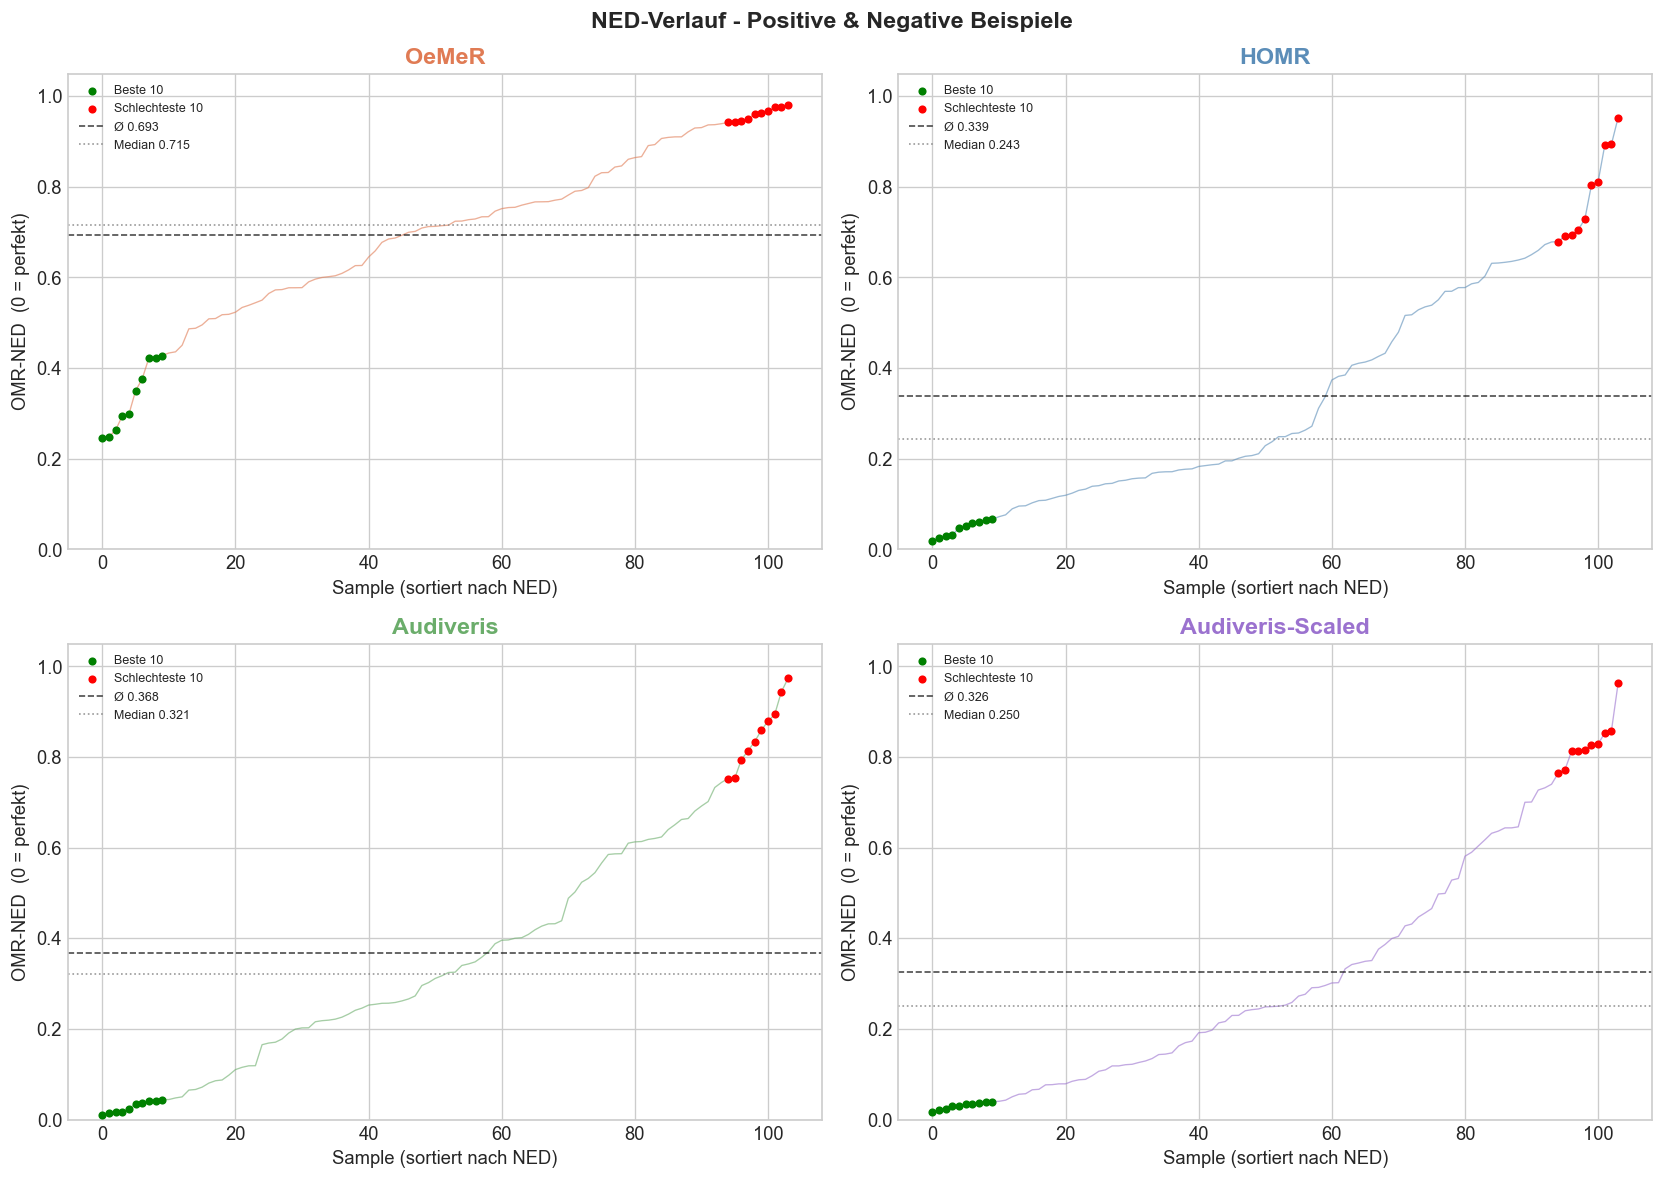

In [59]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (name, df) in zip(axes, frames.items()):
    df_s = df.dropna(subset=[NED_COL]).sort_values(NED_COL)
    ned  = df_s[NED_COL].values
    n    = len(ned)

    ax.plot(range(n), ned, color=PALETTE[name], linewidth=0.8, alpha=0.6)
    
    cut = max(1, n // 10)
    ax.scatter(range(cut), ned[:cut],
               color='green', s=15, zorder=5, label=f'Beste {cut}')
    ax.scatter(range(n - cut, n), ned[n - cut:],
               color='red',   s=15, zorder=5, label=f'Schlechteste {cut}')

    ax.axhline(ned.mean(),   color='black',  linestyle='--', linewidth=1, alpha=0.7,
               label=f'Ø {ned.mean():.3f}')
    ax.axhline(np.median(ned), color='gray', linestyle=':',  linewidth=1, alpha=0.8,
               label=f'Median {np.median(ned):.3f}')

    ax.set_title(name, color=PALETTE[name], fontweight='bold')
    ax.set_xlabel('Sample (sortiert nach NED)')
    ax.set_ylabel('OMR-NED  (0 = perfekt)')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=7.5)

fig.suptitle('NED-Verlauf - Positive & Negative Beispiele', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'ned_sorted_examples.png', dpi=200, bbox_inches='tight')
plt.show()

## 10  Audiveris: Original vs. Scaled

Gemeinsame Samples: 104


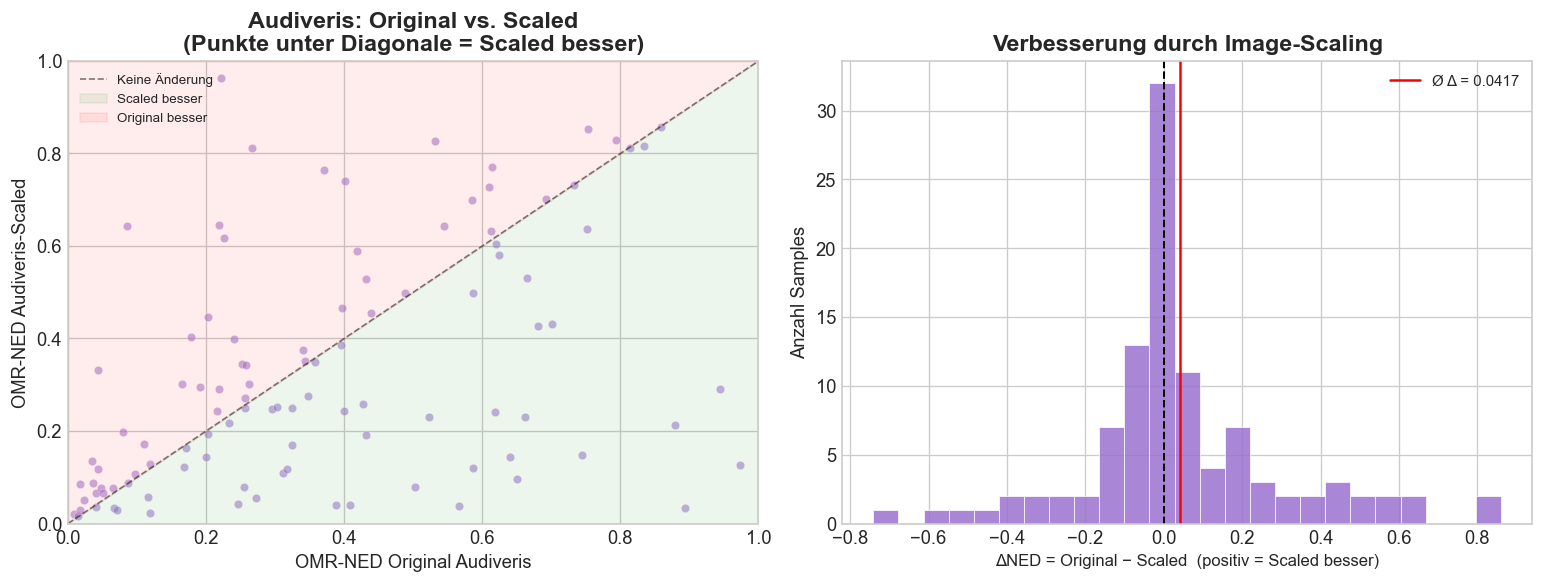

Scaled besser in 50.0% der gemeinsamen Samples
Ø NED-Verbesserung (Scaled): 0.0417


In [60]:
aud_orig   = frames['Audiveris'].set_index('sample_id')[[NED_COL]].rename(columns={NED_COL: 'Original'})
aud_scaled = frames['Audiveris-Scaled'].set_index('sample_id')[[NED_COL]].rename(columns={NED_COL: 'Scaled'})

aud_cmp = aud_orig.join(aud_scaled, how='inner').dropna()
print(f'Gemeinsame Samples: {len(aud_cmp)}')

if len(aud_cmp) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    ax = axes[0]
    ax.scatter(aud_cmp['Original'], aud_cmp['Scaled'],
               alpha=0.55, s=25, color='#9B72CF', edgecolor='white', linewidth=0.3)
    lim = 1.0
    ax.plot([0, lim], [0, lim], 'k--', linewidth=1, alpha=0.5, label='Keine Änderung')
    ax.fill_between([0, lim], [0, lim], [0, 0], alpha=0.07, color='green', label='Scaled besser')
    ax.fill_between([0, lim], [0, lim], [lim, lim], alpha=0.07, color='red', label='Original besser')
    ax.set_xlabel('OMR-NED Original Audiveris')
    ax.set_ylabel('OMR-NED Audiveris-Scaled')
    ax.set_title('Audiveris: Original vs. Scaled\n(Punkte unter Diagonale = Scaled besser)', fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

    ax2 = axes[1]
    diff = aud_cmp['Original'] - aud_cmp['Scaled']
    ax2.hist(diff, bins=25, color='#9B72CF', edgecolor='white', linewidth=0.5, alpha=0.85)
    ax2.axvline(0, color='black', linewidth=1.2, linestyle='--')
    ax2.axvline(diff.mean(), color='red', linewidth=1.5, label=f'Ø Δ = {diff.mean():.4f}')
    ax2.set_xlabel('ΔNED = Original − Scaled  (positiv = Scaled besser)', fontsize=10)
    ax2.set_ylabel('Anzahl Samples')
    ax2.set_title('Verbesserung durch Image-Scaling', fontweight='bold')
    ax2.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(FIG_DIR / 'audiveris_scaled_comparison.png', dpi=200, bbox_inches='tight')
    plt.show()

    pct_better = (diff > 0).mean() * 100
    print(f'Scaled besser in {pct_better:.1f}% der gemeinsamen Samples')
    print(f'Ø NED-Verbesserung (Scaled): {diff.mean():.4f}')
else:
    print('Keine gemeinsamen Sample-IDs gefunden - Vergleich nicht möglich.')

## 11  Zusammenfassung

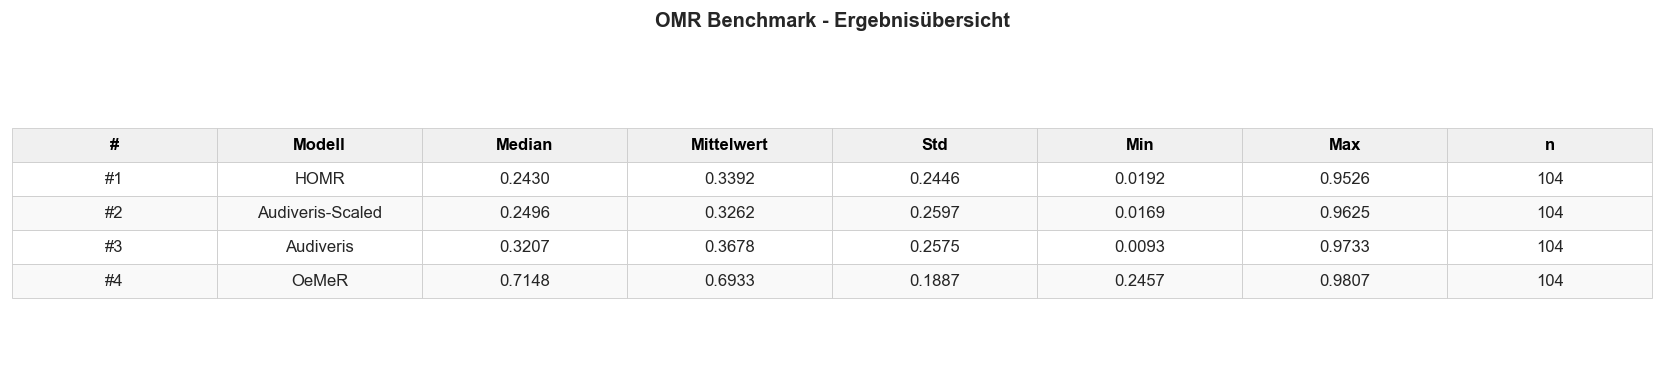

In [61]:
ranked = sorted(frames.items(), key=lambda kv: kv[1][NED_COL].median())

col_labels = ['#', 'Modell', 'Median', 'Mittelwert', 'Std', 'Min', 'Max', 'n']
cell_data = []
for rank, (name, df) in enumerate(ranked, 1):
    ned = df[NED_COL]
    acc = (1 - ned.mean()) * 100
    cell_data.append([
        f'#{rank}', name,
        f'{ned.median():.4f}', f'{ned.mean():.4f}', f'{ned.std():.4f}',
        f'{ned.min():.4f}', f'{ned.max():.4f}',
        str(len(df)),
    ])

fig, ax = plt.subplots(figsize=(14, 1.2 + len(ranked) * 0.55))
ax.axis('off')

tbl = ax.table(
    cellText=cell_data,
    colLabels=col_labels,
    loc='center',
    cellLoc='center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.6)

for (i, j), cell in tbl.get_celld().items():
    cell.set_edgecolor('#cccccc')
    cell.set_linewidth(0.5)
    if i == 0:
        cell.set_facecolor('#f0f0f0')
        cell.set_text_props(fontweight='bold', color='black', fontsize=10)
    else:
        cell.set_facecolor('#f9f9f9' if i % 2 == 0 else 'white')

ax.set_title('OMR Benchmark - Ergebnisübersicht',
             fontsize=12, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig(FIG_DIR / 'summary_table.png', dpi=200, bbox_inches='tight')
plt.show()